In [1]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
if not os.path.isdir('data'):
    os.chdir('..')

print(f"Diretório de trabalho atualizado para: {os.getcwd()}")

Diretório de trabalho atualizado para: /Users/ngodeny/Documents/mestrado/2026-resolucao_problemas/2026_resolucao_problemas


In [ ]:
# Carregando os dados limpos do EDA
caminho_dados = 'data/processed/treino_tratado_clusters.csv'
df_treino = pd.read_csv(caminho_dados, parse_dates=['Data'])

print(f"Dados carregados com sucesso! Tamanho: {df_treino.shape}")

Dados carregados com sucesso! Tamanho: (76, 11)


In [4]:
# 1. Isolando apenas os dias úteis
df_mod = df_treino[~df_treino['Dia da Semana'].isin(['Sábado', 'Domingo'])].copy()

# 2. Criando o Logaritmo do Volume Limpo e do Preço
df_mod['ln_Volume'] = np.log(df_mod['Volume Tratado (kg)'])
df_mod['ln_Preco'] = np.log(df_mod['Preço'])

# 3. Mapeando os Clusters
def define_cluster(dia):
    if dia in ['Segunda', 'Quinta']: return 'Pico'
    elif dia in ['Terça', 'Quarta']: return 'Regular'
    else: return 'Fraco'

df_mod['Cluster'] = df_mod['Dia da Semana'].apply(define_cluster)

# 4. Criando Dummies e a Interação Campeã
dummies = pd.get_dummies(df_mod['Cluster'], prefix='Cluster', dtype=int)
df_mod = pd.concat([df_mod, dummies], axis=1)

# A interação que provou ser estatisticamente relevante no EDA
df_mod['ln_Preco_x_Pico'] = df_mod['ln_Preco'] * df_mod['Cluster_Pico']

print("Variáveis para modelagem criadas com sucesso!")

Variáveis para modelagem criadas com sucesso!


In [5]:
# 1. Definindo as variáveis X (A base 'Regular' fica oculta como intercepto)
variaveis = ['ln_Preco', 'Cluster_Pico', 'Cluster_Fraco', 'ln_Preco_x_Pico']
X = sm.add_constant(df_mod[variaveis])
y = df_mod['ln_Volume']

# 2. Treinando o modelo
modelo_demanda = sm.OLS(y, X).fit()

# 3. Guardando os coeficientes em uma variável para usar no Otimizador
coefs = modelo_demanda.params

print("=== COEFICIENTES TREINADOS E SALVOS ===")
print(modelo_demanda.summary().tables[1])

=== COEFICIENTES TREINADOS E SALVOS ===
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              70.9847     15.610      4.547      0.000      39.770     102.200
ln_Preco           -9.5036      2.183     -4.354      0.000     -13.869      -5.139
Cluster_Pico       57.7307     24.393      2.367      0.021       8.954     106.508
Cluster_Fraco      -1.2156      0.136     -8.942      0.000      -1.487      -0.944
ln_Preco_x_Pico    -8.0433      3.411     -2.358      0.022     -14.864      -1.223


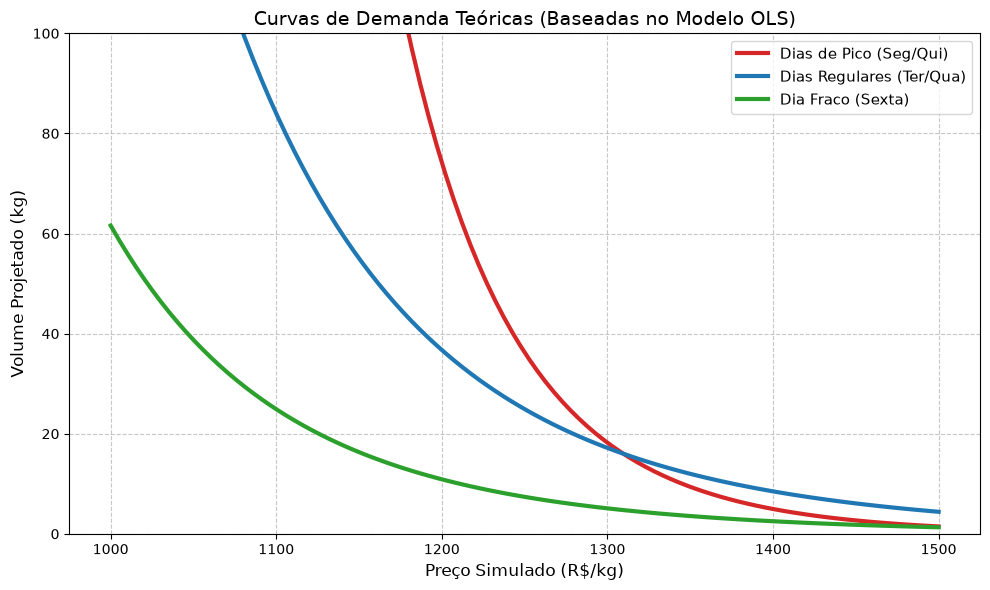

In [7]:
# 1. Criando um espectro de preços simulados (ex: R$ 1000 a R$ 1380)
precos_simulados = np.linspace(1000, 1500, 100)

# 2. Construindo as curvas usando os coeficientes dinâmicos (A * Preço^-B)
# Curva Base (Terça e Quarta)
vol_regular = np.exp(coefs['const']) * (precos_simulados ** coefs['ln_Preco'])

# Curva Fraca (Sexta-feira)
vol_fraco = np.exp(coefs['const'] + coefs['Cluster_Fraco']) * (precos_simulados ** coefs['ln_Preco'])

# Curva Pico (Segunda e Quinta) - Soma das constantes e das elasticidades
const_pico = coefs['const'] + coefs['Cluster_Pico']
elast_pico = coefs['ln_Preco'] + coefs['ln_Preco_x_Pico']
vol_pico = np.exp(const_pico) * (precos_simulados ** elast_pico)

# 3. Plotando o resultado
plt.figure(figsize=(10, 6))

plt.plot(precos_simulados, vol_pico, label='Dias de Pico (Seg/Qui)', color='#d62728', linewidth=3)
plt.plot(precos_simulados, vol_regular, label='Dias Regulares (Ter/Qua)', color='#1f77b4', linewidth=3)
plt.plot(precos_simulados, vol_fraco, label='Dia Fraco (Sexta)', color='#2ca02c', linewidth=3)

plt.title("Curvas de Demanda Teóricas (Baseadas no Modelo OLS)", fontsize=14)
plt.xlabel("Preço Simulado (R$/kg)", fontsize=12)
plt.ylabel("Volume Projetado (kg)", fontsize=12)
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

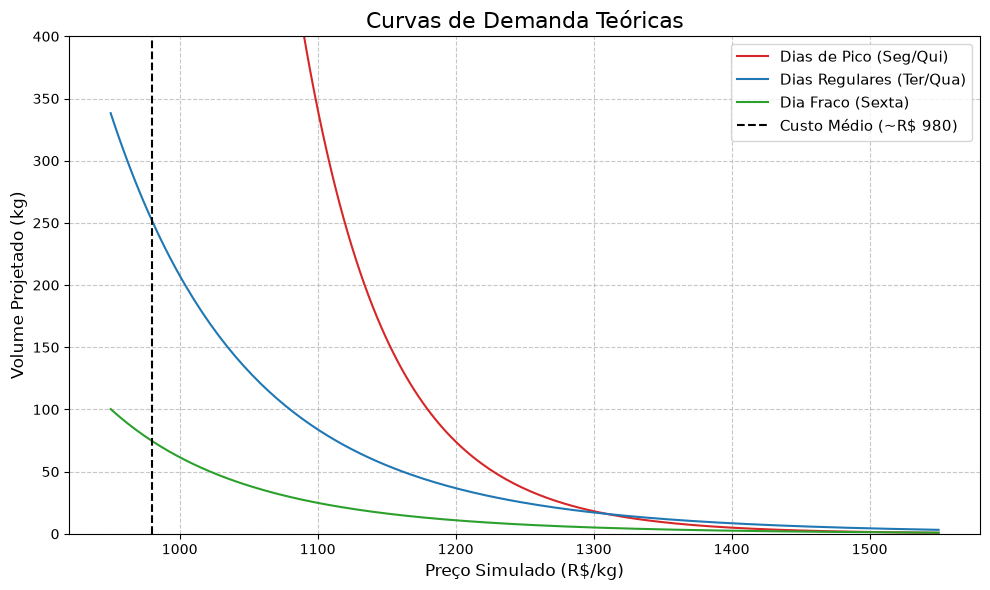

In [17]:
# 1. Ampliando o espectro de preços simulados (R$ 950 a R$ 1550)
precos_simulados = np.linspace(950, 1550, 200)

# 2. Construindo as curvas usando os coeficientes dinâmicos (A * Preço^-B)
# Curva Base (Terça e Quarta)
vol_regular = np.exp(coefs['const']) * (precos_simulados ** coefs['ln_Preco'])

# Curva Fraca (Sexta-feira)
vol_fraco = np.exp(coefs['const'] + coefs['Cluster_Fraco']) * (precos_simulados ** coefs['ln_Preco'])

# Curva Pico (Segunda e Quinta)
const_pico = coefs['const'] + coefs['Cluster_Pico']
elast_pico = coefs['ln_Preco'] + coefs['ln_Preco_x_Pico']
vol_pico = np.exp(const_pico) * (precos_simulados ** elast_pico)

# 3. Plotando o resultado com eixos ampliados
plt.figure(figsize=(10, 6))

plt.plot(precos_simulados, vol_pico, label='Dias de Pico (Seg/Qui)', color='#d62728', linewidth=1.5)
plt.plot(precos_simulados, vol_regular, label='Dias Regulares (Ter/Qua)', color='#1f77b4', linewidth=1.5)
plt.plot(precos_simulados, vol_fraco, label='Dia Fraco (Sexta)', color='#2ca02c', linewidth=1.5)

# Linha indicando onde começa o Prejuízo = Custo Médio
plt.axvline(x=980, color='black', linestyle='--', linewidth=1.5, label='Custo Médio (~R$ 980)')

plt.title("Curvas de Demanda Teóricas", fontsize=16)
plt.xlabel("Preço Simulado (R$/kg)", fontsize=12)
plt.ylabel("Volume Projetado (kg)", fontsize=12)

# Aumentando o limite do Y para 400 kg para vermos a explosão da demanda
plt.ylim(0, 400) 

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()